<a href="https://colab.research.google.com/github/Carmen10-171/03MIAR_Algoritmos-de-Optimizacion/blob/main/03MIAR_MCarmenCopeSoler_AG3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 03MIAR - Algoritmos de optimización
## Actividad guiada 3

*Mª Carmen Copé Soler*

## Presentación

Grupo 2 Actividad guiada 3

https://github.com/Carmen10-171/03MIAR_Algoritmos-de-Optimizacion

## Objetivos
- Comprender el uso de librerías de simulación del problema del agente viajero en Python
- Implementar y visualizar algoritmos de búsqueda basados en metaheurísticas
- Algoritmo de búsqueda aleatoria
- Algoritmo de búsqueda local
- Algoritmo Simulated Annealing

## Librerías y simulación del problema del agente viajero en Python
- Uso de librería tsplib95
- Visualización de datos

In [30]:
!pip install tsplib95
import numpy as np
import tsplib95
import random
from math import e
import math
import copy
import urllib.request

In [31]:
# Descargamos el fichero de datos (Matriz de distancias)
file = "swiss42.tsp" ;
urllib.request.urlretrieve("https://raw.githubusercontent.com/mastqe/tsplib/refs/heads/master/swiss42.tsp", file  )

#urllib.request.urlretrieve("https://raw.githubusercontent.com/mastqe/tsplib/refs/heads/master/swiss42.tsp", file + '.gz')
#!gzip -d swiss42.tsp.gz     #Descomprimir el fichero de datos

#Coordendas 51-city problem (Christofides/Eilon)
#file = "eil51.tsp" ; urllib.request.urlretrieve("http://comopt.ifi.uni-heidelberg.de/software/TSPLIB95/tsp/eil51.tsp.gz", file)

#Coordenadas - 48 capitals of the US (Padberg/Rinaldi)
#file = "att48.tsp" ; urllib.request.urlretrieve("http://comopt.ifi.uni-heidelberg.de/software/TSPLIB95/tsp/att48.tsp.gz", file)


#http://comopt.ifi.uni-heidelberg.de/software/TSPLIB95
#Documentacion :
  # http://comopt.ifi.uni-heidelberg.de/software/TSPLIB95/tsp95.pdf
  # https://tsplib95.readthedocs.io/en/stable/pages/usage.html
  # https://tsplib95.readthedocs.io/en/v0.6.1/modules.html
  # https://pypi.org/project/tsplib95/

('swiss42.tsp', <http.client.HTTPMessage at 0x7dc67ac6c800>)

In [32]:
problema = tsplib95.load(file)
nodos = list(problema.get_nodes())
aristas = list(problema.get_edges())

print(problema) # Descripción estándar
print(nodos) # Nodos 0, 1, 2 ... 42
print(aristas) # Ver https://github.com/mastqe/tsplib/blob/master/swiss42.tsp

NAME: swiss42
COMMENT: 42 Staedte Schweiz (Fricker)
TYPE: TSP
DIMENSION: 42
EDGE_WEIGHT_TYPE: EXPLICIT
EDGE_WEIGHT_FORMAT: FULL_MATRIX
EDGE_WEIGHT_SECTION:
0 15 30 23 32 55 33 37 92 114 92 110 96 90 74 76 82 67 72 78 82 159 122 131 206 112 57 28 43 70 65 66 37 103 84 125 129 72 126 141 183 124
15 0 34 23 27 40 19 32 93 117 88 100 87 75 63 67 71 69 62 63 96 164 132 131 212 106 44 33 51 77 75 72 52 118 99 132 132 67 139 148 186 122
30 34 0 11 18 57 36 65 62 84 64 89 76 93 95 100 104 98 57 88 99 130 100 101 179 86 51 4 18 43 45 95 45 115 93 152 159 100 112 114 153 94
23 23 11 0 11 48 26 54 70 94 69 89 75 84 84 89 92 89 54 78 99 141 111 109 190 89 44 11 29 54 56 89 47 118 96 147 151 90 122 126 163 101
32 27 18 11 0 40 20 58 67 92 61 78 65 76 83 89 91 95 43 72 110 141 116 105 190 81 34 19 35 57 63 97 58 129 107 156 158 92 129 127 161 95
55 40 57 48 40 0 23 55 96 123 78 75 62 36 56 66 63 95 37 34 137 174 156 129 224 90 15 59 75 96 103 105 91 158 139 164 156 78 169 163 191 115
33 19 36 26 20 

23


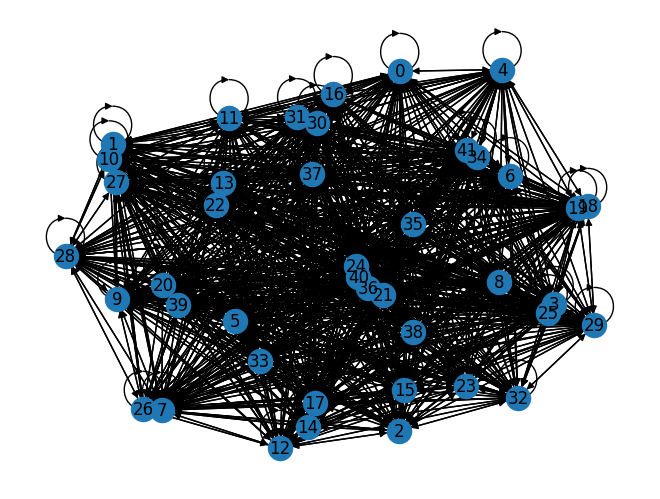

In [33]:
# Probamos algunas funciones del objeto problema, que ya nos vienen dadas

# Distancia entre nodos (ciudades)
distancia = problema.get_weight(3, 0)
print(distancia)

#Todas las funciones
#Documentación: https://tsplib95.readthedocs.io/en/v0.6.1/modules.html
#dir(problema)

import networkx as nx
import matplotlib.pyplot as plt
nx.draw(problema.get_graph(), with_labels=True, arrows=True)
plt.show()

In [34]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from sklearn.manifold import MDS  # Multidimensional Scaling o Escalado Multidimensional

def plot_tsp_solution(distance_matrix, tsp_solution):
    """
    Dibuja el grafo de un TSP con las posiciones calculadas mediante MDS y muestra
    solo las aristas correspondientes a la solución del TSP.

    :param distance_matrix: np.ndarray, matriz de distancias entre nodos
    :param tsp_solution: list, lista de nodos en el orden de la solución del TSP
    """
    # Crear el grafo completo
    G = nx.Graph()
    num_nodes = len(distance_matrix)
    for i in range(num_nodes):
        for j in range(i + 1, num_nodes):
            G.add_edge(i, j, weight=distance_matrix[i][j])

    # Usar MDS para calcular posiciones de los nodos
    mds = MDS(n_components=2, dissimilarity="precomputed", random_state=42)
    positions = mds.fit_transform(distance_matrix)

    # Convertir las posiciones en un diccionario para networkx
    pos = {i: positions[i] for i in range(num_nodes)}

    # Crear un subgrafo con las aristas del camino TSP
    TSP_G = nx.Graph()
    for i in range(len(tsp_solution) - 1):
        u = tsp_solution[i]
        v = tsp_solution[i + 1]
        TSP_G.add_edge(u, v, weight=distance_matrix[u][v])

    # Dibujar el grafo
    plt.figure(figsize=(8, 6))

    # Dibujar nodos
    nx.draw_networkx_nodes(G, pos, node_color='lightblue', node_size=500)

    # Dibujar las aristas del camino TSP
    nx.draw_networkx_edges(TSP_G, pos, edge_color='red', width=2)

    # Añadir etiquetas a los nodos y pesos de las aristas
    nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold')
    edge_labels = nx.get_edge_attributes(TSP_G, 'weight')
    nx.draw_networkx_edge_labels(TSP_G, pos, edge_labels=edge_labels, font_size=8)

    plt.title("Grafo TSP con solución específica")
    plt.show()

## Funciones básicas para algoritmos de búsqueda

In [35]:
# Genera una solución aleatoria con comienzo en en el nodo 0
def crear_solucion(nodos):
    # Nodo inicial = 0
    solucion = [nodos[0]]
    # Para el resto de nodos, los recorremos e incluimos aleatoriamente en la solución cada uno de ellos
    for n in nodos[1:]:
        # Debemos quitar el nodo 0 y los ya incluidos en cada iteración
        solucion = solucion + [random.choice(list(set(nodos) - set({nodos[0]}) - set(solucion)))]
    return solucion


# Devuelve la distancia entre dos nodos aprovechando la función get_weight() de tsplib95
def distancia(a,b, problema):
    return problema.get_weight(a,b)


# Devuelve la distancia total de una trayectoria/solución
def distancia_total(solucion, problema):
    distancia_total = 0
    # Para cada nodo de la solución calculamos su distancia a siguiente nodo
    for i in range(len(solucion)-1):
        distancia_total += distancia(solucion[i] ,solucion[i+1] ,  problema)
    # Devolvemos la distancia total más la distancia del último nodo al primero para cerrar viaje
    return distancia_total + distancia(solucion[len(solucion)-1] ,solucion[0], problema)


solucion = crear_solucion(nodos)
print(solucion)
print(distancia_total(solucion, problema))

[0, 6, 4, 26, 2, 20, 23, 19, 30, 14, 37, 1, 11, 25, 24, 12, 10, 28, 27, 35, 40, 21, 16, 5, 8, 13, 39, 18, 7, 38, 31, 15, 22, 29, 34, 3, 9, 33, 17, 36, 32, 41]
4608


## Búsqueda aleatoria - TSP
- El algoritmo inicializa soluciones al azar y se queda con la mejor que encuentre
- Se realizan N iteraciones y nos quedamos con la mejor
- Todo es azar, sin que garanticemos solución óptima

Solución: [0, 35, 6, 37, 28, 11, 10, 8, 12, 26, 20, 32, 31, 2, 36, 14, 16, 23, 40, 9, 4, 38, 22, 21, 24, 3, 7, 17, 15, 30, 13, 39, 29, 19, 5, 18, 34, 33, 25, 41, 1, 27]
Distancia: 3746


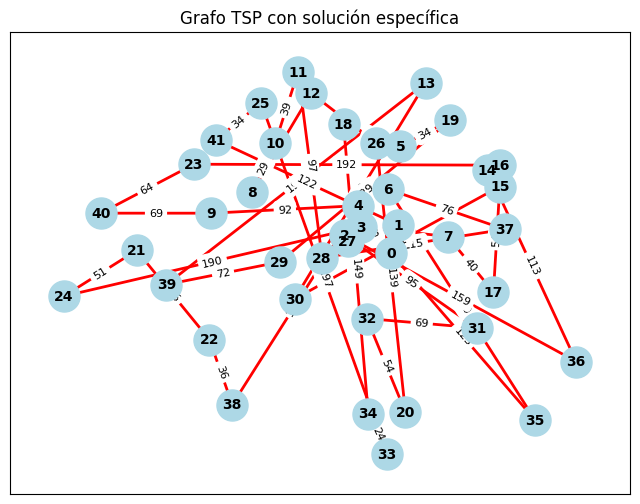

In [36]:
def busqueda_aleatoria(problema, iteraciones):
    # Obtenemos listado de nodos del problema
    nodos = list(problema.get_nodes())

    mejor_solucion = []
    mejor_distancia_total = float("inf")

    for i in range(iteraciones):
        # Generamos solución aleatoria
        solucion = crear_solucion(nodos)
        # Calculamos distancia total de la solución
        distancia = distancia_total(solucion, problema)
        if (distancia < mejor_distancia_total):
            mejor_solucion = solucion
            mejor_distancia_total = distancia

    return mejor_solucion, mejor_distancia_total

iteraciones = 5000
mejor_solucion, mejor_distancia_total = busqueda_aleatoria(problema, iteraciones)

print(f"Solución: {mejor_solucion}")
print(f"Distancia: {mejor_distancia_total}")

plot_tsp_solution(problema.edge_weights, mejor_solucion)



## Búsqueda local - TSP
- El algoritmo se va quedando con vecinos (operadores de vecindad) para intentar converger a mejores soluciones
- Se realizan N iteraciones y nos quedamos con la mejor

In [37]:
# Función que a partir de una solución genera la vecina óptima (es decir, la mejor vecina de todas las que existen)
def genera_mejor_vecina(solucion):
    # Generador de soluciones vecinas: 2-opt (intercambiar 2 nodos) Si hay N nodos se generan (N-1)x(N-2)/2 soluciones en el bucle
    # Se puede modificar para aplicar otros generadores distintos que 2-opt como inversión, barajado...
    #print(solucion)

    mejor_solucion = []
    mejor_distancia = float("inf")

    #Recorremos todos los nodos en bucle doble para evaluar todos los intercambios 2-opt
    for i in range(1,len(solucion)-1):
        for j in range(i+1, len(solucion)):
            # Generamos nueva solución vecina (0, 1, 2, 3, i, ..., j, ..., 41) -> (0, 1, 2, 3, j, ..., i, ..., 41)
            vecina = solucion[:i] + [solucion[j]] + solucion[i+1:j] + [solucion[i]] + solucion[j+1:]

            # Se evalua la nueva solución
            distancia_vecina = distancia_total(vecina, problema)

            # Si es la mejor solución, la almacenamos
            if (distancia_vecina <= mejor_distancia):
                mejor_distancia = distancia_vecina
                mejor_solucion = vecina

    # Devolvemos mejor vecina
    return mejor_solucion


solucion = crear_solucion(nodos)
print(f"Distancia Solucion Incial: {distancia_total(solucion, problema)}")

nueva_solucion = genera_mejor_vecina(solucion)
print(f"Distancia Mejor Solucion Local: {distancia_total(nueva_solucion, problema)}")

Distancia Solucion Incial: 4489
Distancia Mejor Solucion Local: 4085


En la iteracion 38 la mejor solución encontrada es: [0, 1, 11, 12, 18, 26, 6, 4, 3, 2, 27, 30, 38, 22, 39, 24, 40, 21, 9, 23, 41, 29, 34, 33, 20, 32, 28, 8, 25, 10, 7, 17, 31, 35, 36, 37, 15, 5, 13, 19, 16, 14]
Distancia: 1742


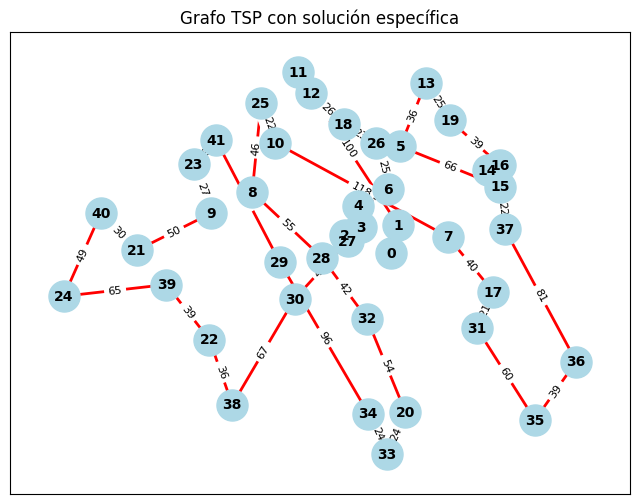

In [38]:
# En este caso, la búsqueda se ejecuta sin criterio de parada, se para cuando no es posible mejorar.
# Aquí iremos recorriendo las mejores vecinas para ir construyendo trayectoria
def busqueda_local(problema):
    mejor_solucion = []

    # Generar una solucion inicial de referencia(aleatoria)
    solucion_referencia = crear_solucion(nodos)
    mejor_distancia = distancia_total(solucion_referencia, problema)

    # Contador de iteraciones (por tener referencia)
    iteracion = 0

    while(1):
        iteracion += 1
        #print('#',iteracion)

        # Obtenemos la mejor vecina
        vecina = genera_mejor_vecina(solucion_referencia)

        # Evaluamos para ver si mejoramos respecto a lo encontrado hasta el momento
        distancia_vecina = distancia_total(vecina, problema)

        # Si mejoramos hay que seguir
        if (distancia_vecina < mejor_distancia):
            #mejor_solucion = copy.deepcopy(vecina)   # Con copia profunda. Las copias en python son por referencia
            mejor_solucion = vecina                   # Guarda la mejor solución encontrada
            mejor_distancia = distancia_vecina

        # Si no mejoramos, retornamos ya que hemos llegado a un minimo local (según nuestro operador de vecindad 2-opt)
        else:
            #print(f"En la iteracion {iteracion} la mejor solución encontrada es: {mejor_solucion}")
            #print(f"Distancia: {mejor_distancia}")
            return mejor_solucion, mejor_distancia, iteracion

        solucion_referencia = vecina


mejor_solucion, mejor_distancia, iteracion = busqueda_local(problema)
print(f"En la iteracion {iteracion} la mejor solución encontrada es: {mejor_solucion}")
print(f"Distancia: {mejor_distancia}")

plot_tsp_solution(problema.edge_weights, mejor_solucion)

## 1ª Mejora: Multiarranque (Multi‑Start Local Search, MLS)
La búsqueda local clásica cae en mínimos locales.
Para evitarlo, repetimos el proceso muchas veces, cada vez con una solución inicial aleatoria.

Al final nos quedamos con la mejor de todas.
- Muy fácil de implementar

- Escala bien

- Aumenta la probabilidad de encontrar soluciones cercanas al óptimo



In [39]:
def multiarranque(problema, num_arranques=20):
    mejor_global = None
    mejor_dist_global = float("inf")

    for k in range(num_arranques):
        solucion, dist, it = busqueda_local(problema)

        if dist < mejor_dist_global:
            mejor_global = solucion
            mejor_dist_global = dist

    return mejor_global, mejor_dist_global

Ejecución

Mejor distancia encontrada: 1573


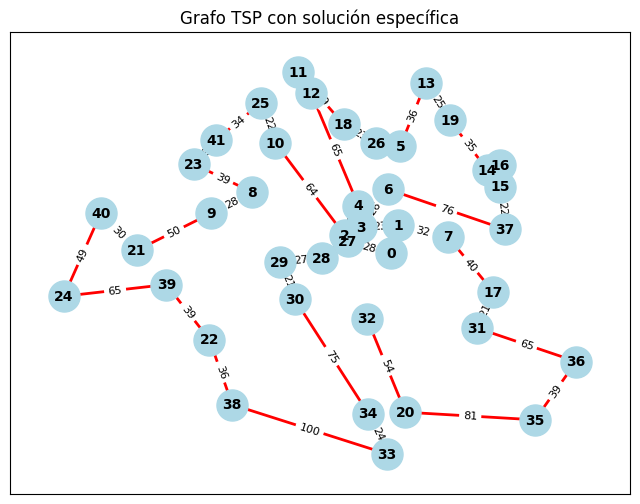

In [40]:
sol, dist = multiarranque(problema, num_arranques=30)
print("Mejor distancia encontrada:", dist)
plot_tsp_solution(problema.edge_weights, sol)

## 2ª Mejora - Búsqueda en Entornos Variables (VNS)
La búsqueda local usa un único operador de vecindad (2‑opt).
Pero a veces el mínimo local de 2‑opt no es mínimo local de 3‑opt, ni de intercambio, ni de inserción…

VNS cambia de entorno cuando se atasca.
Entornos para TSP
- 2‑opt (inversión de segmento)

- 3‑opt (romper 3 aristas y reconectar)

- swap (intercambiar dos nodos)

- insertion (mover un nodo a otra posición)

Código VNS básico, definimos los operadores simples:

In [41]:
def swap(sol, i, j):
    nueva = sol[:]
    nueva[i], nueva[j] = nueva[j], nueva[i]
    return nueva

def insertion(sol, i, j):
    nueva = sol[:]
    nodo = nueva.pop(i)
    nueva.insert(j, nodo)
    return nueva


Generamos VNS

In [42]:
def VNS(problema, max_k=3):
    # Solución inicial
    sol = crear_solucion(nodos)
    dist = distancia_total(sol, problema)

    k = 1

    while k <= max_k:

        # 1. Shaking: generar solución aleatoria en entorno k
        if k == 1:
            i, j = random.sample(range(1, len(sol)-1), 2)
            vecina = swap(sol, i, j)

        elif k == 2:
            i, j = random.sample(range(1, len(sol)-1), 2)
            vecina = insertion(sol, i, j)

        elif k == 3:
            vecina = sol[:]
            random.shuffle(vecina)

        # 2. Búsqueda local desde la vecina
        mejor_vecina, dist_vecina, _ = busqueda_local(problema)

        # 3. Si mejora, reiniciamos k
        if dist_vecina < dist:
            sol = mejor_vecina
            dist = dist_vecina
            k = 1
        else:
            k += 1

    return sol, dist

Ejecucion:

Mejor distancia VNS: 1655


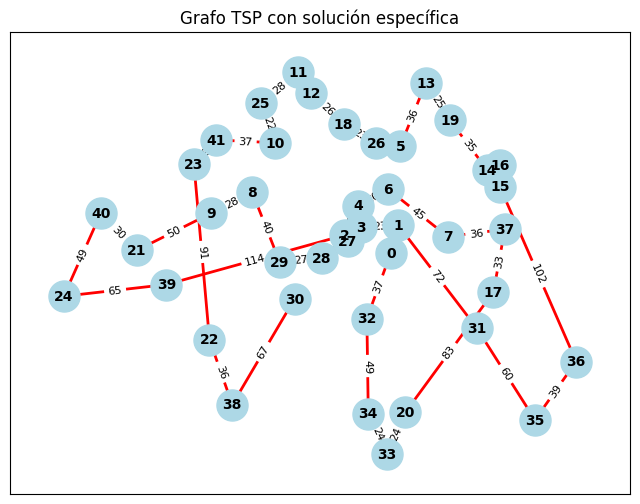

In [43]:
sol, dist = VNS(problema, max_k=3)
print("Mejor distancia VNS:", dist)
plot_tsp_solution(problema.edge_weights, sol)

## Recocido simulado (Simulated Annealing) - TSP
- El algoritmo se va quedando con vecinos (operadores de vecindad) para intentar converger a mejores soluciones, aunque ahora a veces puedo elegir vecinos peores
- Al principio, elijo más veces vecinos peores (diversifico) y luego elijo menos veces esos vecinos peores (intensifico)
- Se realizan N iteraciones o bajamos temperatura al máximo

### Funciones auxiliares

In [44]:
# Generador de 1 solucion vecina 2-opt 100% aleatoria (intercambiar 2 nodos)
def genera_vecina_aleatorio(solucion):

  # Se eligen dos nodos aleatoriamente
  i,j = sorted(random.sample(range(1,len(solucion)) , 2))

  # Devuelve una nueva solución pero intercambiando los dos nodos elegidos al azar
  return solucion[:i] + [solucion[j]] + solucion[i+1:j] + [solucion[i]] + solucion[j+1:]


# Funcion de probabilidad para aceptar peores soluciones
def probabilidad(T, d):
  if random.random() <  math.exp(-1*d / T)  :
    return True
  else:
    return False


# Funcion de descenso de temperatura
def bajar_temperatura(T):
  return T*0.999

La mejor solución encontrada es: [0, 7, 17, 31, 36, 35, 20, 33, 34, 32, 4, 18, 12, 11, 25, 10, 41, 23, 9, 8, 29, 30, 38, 22, 39, 24, 40, 21, 28, 2, 27, 3, 37, 15, 16, 14, 19, 13, 5, 26, 6, 1] en 25316 iteraciones
Distancia: 1479


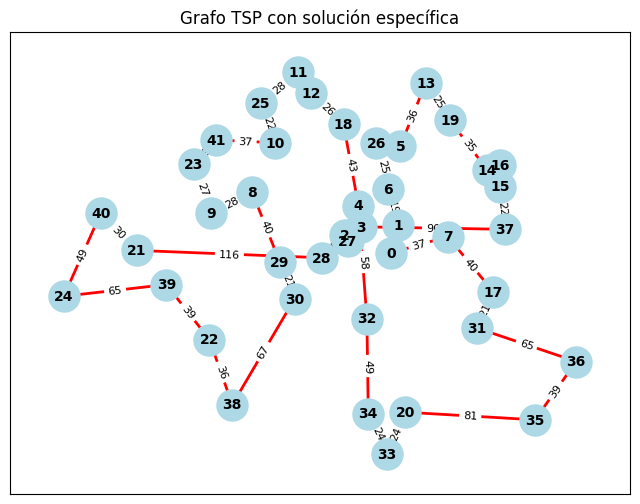

In [45]:
def recocido_simulado(problema, temperatura):
    # Generamos solución de referencia
    solucion_referencia = crear_solucion(nodos)
    distancia_referencia = distancia_total(solucion_referencia, problema)

    mejor_solucion = []
    mejor_distancia = float("inf")

    iteraciones = 0

    # Mientras la temperatura no sea 0 (aquí no hay parada por iteraciones)
    while temperatura > .0001:
        iteraciones += 1

        # Genera una solución vecina
        vecina = genera_vecina_aleatorio(solucion_referencia)

        # Calculamos distancia
        distancia_vecina = distancia_total(vecina, problema)

        # Si es la mejor solución de todas se guarda siempre
        if (distancia_vecina < mejor_distancia):
            mejor_solucion = vecina
            mejor_distancia = distancia_vecina

        # Si la nueva vecina es o
        # Si el vecino es peor se cambia según una probabilidad que depende de T y delta(distancia_referencia - distancia_vecina)
        if ((distancia_vecina < distancia_referencia) or probabilidad(temperatura, abs(distancia_referencia - distancia_vecina))):
            #solucion_referencia = copy.deepcopy(vecina)
            solucion_referencia = vecina
            distancia_referencia = distancia_vecina

        # Bajamos la temperatura
        temperatura = bajar_temperatura(temperatura)

    return mejor_solucion, mejor_distancia, iteraciones

temperatura = 10000000
mejor_solucion, mejor_distancia, iteraciones  = recocido_simulado(problema, temperatura)

print(f"La mejor solución encontrada es: {mejor_solucion} en {iteraciones} iteraciones")
print(f"Distancia: {mejor_distancia}")

plot_tsp_solution(problema.edge_weights, mejor_solucion)

## Recocido simulado - Mejora en seleccion de vecinos
La clave de esta mejora es que el operador de vecindad ya no es solo swap, sino una vecindad híbrida y adaptativa:
- 2‑opt → mejora fuerte de estructura

- inserción → reordena nodos. Extrae un nodo y lo coloca en otra posición.

- swap → ajuste fino. Intercambia dos nodos, útil para micro‑mejoras.

- Movimientos grandes cuando la temperatura T es alta. Barajar parcialmente la solución para escapar de mínimos profundos.

La clave de la mejora es que el tipo de movimiento depende de la temperatura:

- Temperatura alta → exploración global  
  Movimientos grandes + 2‑opt aleatorio.

- Temperatura media → mejoras estructurales  
  2‑opt dirigido + inserción.

- Temperatura baja → ajuste fino  
  Swap o inserción corta.

Esto hace que el algoritmo:

- Explore más al principio

- Se refine al final

- Evite mínimos locales profundos (estancarse)

- Converja a soluciones de mayor calidad



In [46]:
def genera_vecina(solucion):
    n = len(solucion)

    r = random.random()

    # 70% → operador 2-opt
    if r < 0.7:
        i, j = sorted(random.sample(range(1, n), 2))
        nueva = solucion[:i] + list(reversed(solucion[i:j])) + solucion[j:]
        return nueva

    # 20% → operador de inserción
    elif r < 0.9:
        i, j = random.sample(range(1, n), 2)
        nueva = solucion[:]
        nodo = nueva.pop(i)
        nueva.insert(j, nodo)
        return nueva

    # 10% → swap simple (tu operador original)
    else:
        i, j = sorted(random.sample(range(1, n), 2))
        nueva = solucion[:i] + [solucion[j]] + solucion[i+1:j] + [solucion[i]] + solucion[j+1:]
        return nueva

In [47]:
def probabilidad(T, d):
    return random.random() < math.exp(-d / T)


def bajar_temperatura(T):
    return T * 0.999


def recocido_simulado(problema, temperatura):
    solucion_referencia = crear_solucion(nodos)
    distancia_referencia = distancia_total(solucion_referencia, problema)

    mejor_solucion = solucion_referencia[:]
    mejor_distancia = distancia_referencia

    iteraciones = 0

    while temperatura > 0.0001:
        iteraciones += 1

        # Nuevo vecino mejorado
        vecina = genera_vecina(solucion_referencia)

        distancia_vecina = distancia_total(vecina, problema)

        # Actualizar mejor global
        if distancia_vecina < mejor_distancia:
            mejor_solucion = vecina
            mejor_distancia = distancia_vecina

        # Aceptación
        delta = distancia_vecina - distancia_referencia
        if delta < 0 or probabilidad(temperatura, abs(delta)):
            solucion_referencia = vecina
            distancia_referencia = distancia_vecina

        temperatura = bajar_temperatura(temperatura)

    return mejor_solucion, mejor_distancia, iteraciones

Ejecución

La mejor solución encontrada es: [0, 1, 7, 14, 16, 15, 37, 17, 36, 35, 31, 20, 33, 34, 38, 22, 39, 21, 24, 40, 9, 23, 41, 25, 11, 12, 10, 8, 29, 30, 28, 27, 2, 3, 4, 18, 26, 13, 19, 5, 6, 32] en 25316 iteraciones
Distancia: 1404


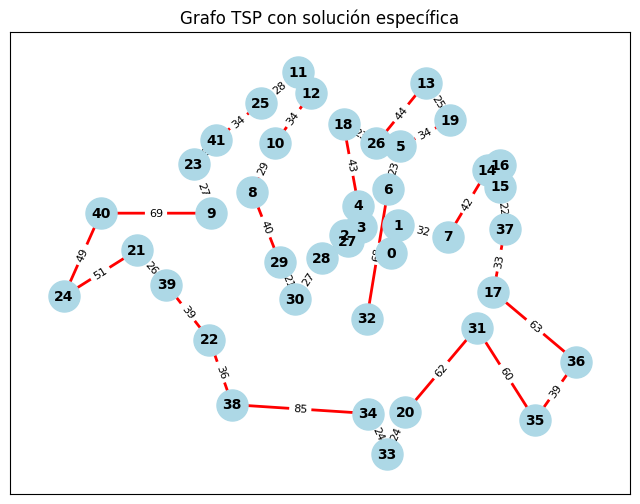

In [48]:
temperatura = 10000000
mejor_solucion, mejor_distancia, iteraciones = recocido_simulado(problema, temperatura)

print(f"La mejor solución encontrada es: {mejor_solucion} en {iteraciones} iteraciones")
print(f"Distancia: {mejor_distancia}")

plot_tsp_solution(problema.edge_weights, mejor_solucion)

## Actividades extra
- Mejora de algoritmo de búsqueda local
  - Multiarranque
  - Búsqueda en entornos variables

- Recocido simulado
  - Mejora en la selección de vecinos